In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="2,3"

%load_ext autoreload
%autoreload 2


In [ ]:
import os
import sys


PROJECT_ROOT = os.getcwd()
if os.path.basename(PROJECT_ROOT) == "notebooks_causal_cactus":
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.DataReaders import *
from src.address import *
from src.modelGen import *
from src.utils import cf_eval, cleanup_gpu, LOF_context_score
from models import CF_CausalCondLatentCF, CF_LatentCFpp, CF_PrototypeCF, CF_CondLatentCF
import numpy as np
import random 
from tensorflow import random as tf_random
import pandas as pd
import tensorflow as tf


In [3]:
SEED = 32

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf_random.set_seed(SEED)


CF_METHODS = {  
    "LatentCFpp": CF_LatentCFpp,
    "Prototype": CF_PrototypeCF,
    "CausalCACTUS": CF_CausalCondLatentCF,
    "CACTUS": CF_CondLatentCF
}


In [4]:

EXP_CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "experiments", "GERMANCREDIT_EXP.json")
with open(EXP_CONFIG_PATH, encoding="utf-8") as f:
    EXP = json.load(f)

In [ ]:
# Loading data
CLASS_CONFIG_PATH = EXP[0]["classifier"]
class_config = get_exp_config(CLASS_CONFIG_PATH)
data   = getData(class_config)

# Getting the classifier
classifier = modelGen(class_config["type"], data,params=class_config, debug=True)
classifier.load()

In [6]:
# Select test data
X_test = data.X_test
y_test_onehot = data.y_test
context_test = data.context_test

context_labels = ["Female","Male"]

X_original = []
y_original_onehot = []
context_original = []

N =10
SELECTED_IDX = []

for val, lbl in enumerate(context_labels):
    idx = np.argwhere(context_test["Sex"].values == val)[:,0]
    idx = np.random.choice(idx, N)

    SELECTED_IDX += idx.tolist()

    X_original.append(X_test[idx])
    y_original_onehot.append(y_test_onehot[idx])
    context_original.append(context_test.values[idx])

X_original = np.vstack(X_original)
y_original_onehot = np.vstack(y_original_onehot)
context_original = np.vstack(context_original)

lof_original = LOF_context_score(
    data.X_train,
    data.context_train.values,
    X_original,
    context_original,
    agg=False
)

In [7]:
import re
from collections import defaultdict
# TODO: make a function to convert the causal paths for all the test samples
def build_causal_index_map(input_features, graph_str):
    """
    Returns:
        child_to_parents: dict {child_idx: [parent_idx, ...]}
        parent_to_children: dict {parent_idx: [child_idx, ...]}
        feat2idx: dict {feature_name: index}
    """

    # Feature name to index
    feat2idx = {f: i for i, f in enumerate(input_features)}

    # Extract edges using regex
    edges = re.findall(r'(\w+)\s*->\s*(\w+)', graph_str)

    child_to_parents = defaultdict(list)
    parent_to_children = defaultdict(list)

    for parent, child in edges:

        if parent not in feat2idx or child not in feat2idx:
            raise ValueError(f"Feature in graph not found in dataset: {parent} or {child}")

        p_idx = feat2idx[parent]
        c_idx = feat2idx[child]

        child_to_parents[c_idx].append(p_idx)
        parent_to_children[p_idx].append(c_idx)

    return dict(child_to_parents), dict(parent_to_children), feat2idx

# credit_rex5_constraints_min.dot from downsampled

# credit_rex6_constraints_mod.dot from downsampled
graph_str2 = """ 
strict digraph {
CreditAmount;
Duration;
Age;
CheckingAccount;
Sex;
Job;
SavingAccounts;
Housing;
SavingAccounts -> Job;
SavingAccounts -> CheckingAccount;
Housing -> CheckingAccount;
Housing -> Job;
}
"""


In [ ]:

#########
# Context-preserving CF generation
#########
X_cf_list = []
y_cf_labels_list = []
X_internal_list = []
y_internal_list = []
lof_cf_list = []
cf_scores_list = []
cf_scores_labels_list = []

for exp_id, exp in enumerate(EXP):

    AE_CONFIG_PATH = exp["AEmodel"]
    AE_config = get_exp_config(AE_CONFIG_PATH)

    ae_model = modelGen(
        AE_config["type"],
        data,
        params=AE_config,
        debug=True
    )
    ae_model.load()

    y_original_labels = np.argmax(y_original_onehot, axis=1)
    y_original_logits = classifier.predict(X_original)

    # NOTE: updated
    child_to_parents_dict, parent_to_children_dict, feat2idx = build_causal_index_map(
        data.features_lbls,
        graph_str2
    )
    print("Feature → index:")
    print(feat2idx)
    print("\nChild → Parents (index form):")
    print(child_to_parents_dict)

    if exp["name"] == "CausalCACTUS":
        CF_method = CF_METHODS[exp["CFmethod"]](
            classifier=classifier,
            # gen=aeModel,
            gen=ae_model,
            params=exp,
            x=data.X_train,
            y=data.y_train,
            x_min=data.X_train.min(axis=0),
            x_max=data.X_train.max(axis=0),
            causal_index_map=child_to_parents_dict
        )
    else:
        CF_method = CF_METHODS[exp["CFmethod"]](
            classifier=classifier,
            # gen=aeModel,
            gen=ae_model,
            params=exp,
            x=data.X_train,
            y=data.y_train
        )

    X_cf, y_cf_labels, X_internal, y_internal = CF_method.transform(
        X_original,
        y_original_labels,
        target_context=context_original
    )

    lof_cf = LOF_context_score(
        data.X_train,
        data.context_train.values,
        X_cf,
        context_original,
        agg=False
    )
    
    # --- CF evaluation ---
    cf_scores, cf_scores_labels = cf_eval(
        X_train=data.X_train, # previous name: data.X_train
        context_train=data.context_train, # previous name: context_training,
        X=X_internal, # previous name: x,
        CF_X=X_cf, # previous name: cf_x, 
        pred_labels=y_original_labels, # previous name: y_,
        target_context=context_original, # previous name: context,
        CF_labels=y_cf_labels, # previous name: cf_y_
        X_unscaled=data.scaler_inverse_transform(X_internal),
        CF_X_unscaled=data.scaler_inverse_transform(X_cf),
        child_to_parents_dict=child_to_parents_dict,
        average=False
    )

    # X_cf = data.scaler_inverse_transform(X_cf) # TODO: non scale

    X_cf_list.append(X_cf)
    y_cf_labels_list.append(y_cf_labels)
    X_internal_list.append(X_internal)
    y_internal_list.append(y_internal)
    lof_cf_list.append(lof_cf)
    cf_scores_list.append(cf_scores)
    cf_scores_labels_list.append(cf_scores_labels)

    cleanup_gpu()


In [9]:

# Original samples 
X_original_unscaled = data.scaler_inverse_transform(X_original)
# Denormalized CF samples 
X_cf_unscaled_list = [data.scaler_inverse_transform(x_cf)  for x_cf in X_cf_list] 


exp_names = ["LatentCF++", "Prototype C","Prototype D","CACTUS","CausalCAC"]



def build_comparison_table_unscaled(sample_idx):

    #x0 = X_original[sample_idx]
    x0 = X_original_unscaled[sample_idx]
    y0 = y_original_labels[sample_idx]
    lof0 = lof_original[sample_idx]
    ctx0 = context_original[sample_idx]
    rows = []

    for feat_idx, feat_name in enumerate(data.features_lbls):

        row = {
            "Feature": feat_name,
            "x0": round(x0[feat_idx], 2),
            "y0": y0,
            "ctx0": ctx0
        }

        for exp_id, exp in enumerate(EXP):
            #cf_sample = X_cf_list[exp_id][sample_idx]
            cf_sample = X_cf_unscaled_list[exp_id][sample_idx]
            cf_val = cf_sample[feat_idx]
            delta = cf_val - x0[feat_idx]
            
            name = exp_names[exp_id]
            row[name] = round(cf_val, 2)
            row[f"Δ_{name}"] = round(delta, 2)

        rows.append(row)

    df = pd.DataFrame(rows)
    df["Feature"] = ['Credit Amount',
                'Duration',
                'Checking Account',
                'Job',
                'Housing',
                'Saving Accounts']
                        
    # Reordering columns by meaning
    order = ['Checking Account',
            'Saving Accounts',
            'Job',
            'Housing',
            'Credit Amount',
            'Duration']
    
    df.index = df["Feature"]
    df = df.reindex(order)
    return df

# Selecting example
idx_example = 3

df_example_credit = build_comparison_table_unscaled(sample_idx=idx_example)

df_example_credit

,Feature,x0,y0,ctx0,LatentCF++,Δ_LatentCF++,Prototype C,Δ_Prototype C,Prototype D,Δ_Prototype D,CACTUS,Δ_CACTUS,CausalCAC,Δ_CausalCAC
Feature,,,,,,,,,,,,,,
Checking Account,Checking Account,1,0,"[0, 1]",1,0,4,3,-1,-2,1,0,1,0
Saving Accounts,Saving Accounts,0,0,"[0, 1]",1,1,-4,-4,1,1,1,1,1,1
Job,Job,3,0,"[0, 1]",3,0,4,1,3,0,2,-1,2,-1
Housing,Housing,0,0,"[0, 1]",1,1,-4,-4,1,1,0,0,0,0
Credit Amount,Credit Amount,5129,0,"[0, 1]",2190,-2939,-4147,-9276,11699,6570,2129,-3000,3291,-1838
Duration,Duration,9,0,"[0, 1]",12,3,-29,-38,9,0,15,6,21,12


/tmp/ipykernel_2076447/3247280353.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.                 nan  0.                 nan -0.57301618  0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pct_df.iloc[:, 1:] = df_example_credit[delta_cols].values / den[:, None]
/tmp/ipykernel_2076447/3247280353.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 3.                 nan  0.33333333         nan -1.80853968 -4.22222222]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pct_df.iloc[:, 1:] = df_example_credit[delta_cols].values / den[:, None]
/tmp/ipykernel_2076447/3247280353.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-2.                 nan  0.                 nan 

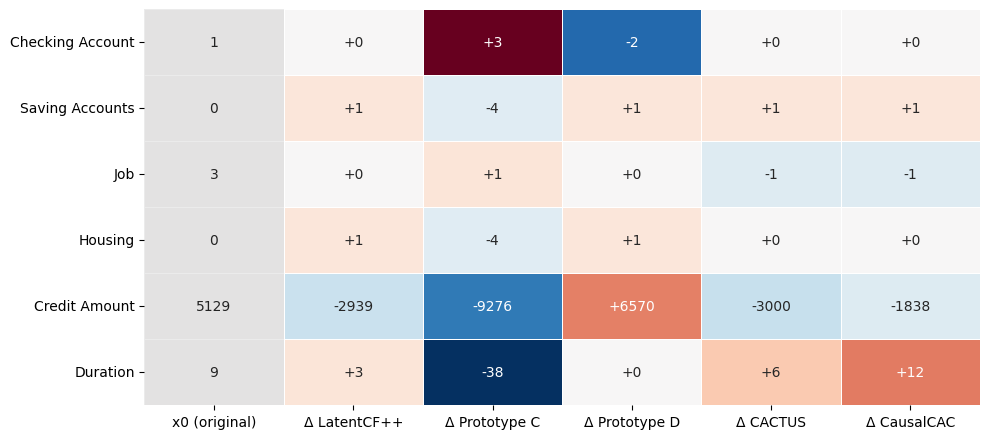

In [10]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 0) Columns of interest ---
delta_cols = [c for c in df_example_credit.columns if c.startswith("Δ_")]

# --- 1) DataFrame for annotations (original units): x0 + deltas ---
annot_df = pd.concat([df_example_credit["x0"], df_example_credit[delta_cols]], axis=1).copy()
annot_df = annot_df.rename(columns={"x0": "x (original)"})
annot_df.columns = [c.replace("Δ_", "Δ ") for c in annot_df.columns]

# --- 2) DataFrame for color: % relative change (delta / x0) ---
pct_df = pd.concat([df_example_credit["x0"], df_example_credit[delta_cols]], axis=1).copy()
pct_df = pct_df.rename(columns={"x0": "x0 (original)"})
pct_df.columns = [c.replace("Δ_", "Δ ") for c in pct_df.columns]

# x0 column in a neutral color (it is not a change)
pct_df.iloc[:, 0] = 0.0

# %Δ = Δ / max(|x0|, eps)
eps = 1e-9
x0_abs = df_example_credit["x0"].abs().replace(0, np.nan)
den = np.maximum(x0_abs.values, eps)
pct_df.iloc[:, 1:] = df_example_credit[delta_cols].values / den[:, None]

# --- 3) Sort rows semantically ---

order = ['Checking Account',
            'Saving Accounts',
            'Job',
            'Housing',
            'Credit Amount',
            'Duration']
    
order = [f for f in order if f in annot_df.index]
annot_df = annot_df.reindex(order)
pct_df = pct_df.reindex(order)

# --- 4) Annotations WITHOUT units + NaN->0 + minimum clipping ---
def fmt_value(feature, x, is_delta=False):
    if "Income" in feature:
        return f"{x:+,.0f}" if is_delta else f"{x:,.0f}"
    if "Ratio" in feature or "Utilization" in feature:
        return f"{x:+.2f}" if is_delta else f"{x:.2f}"
    return f"{x:+.0f}" if is_delta else f"{x:.0f}"

annot_text = annot_df.copy().astype(object)
for feat in annot_df.index:
    val0 = annot_df.loc[feat, annot_df.columns[0]]
    if pd.isna(val0):
        val0 = 0.0
    annot_text.loc[feat, annot_df.columns[0]] = fmt_value(feat, val0, is_delta=False)

    for col in annot_df.columns[1:]:
        val = annot_df.loc[feat, col]
        if pd.isna(val):
            val = 0.0
        if (abs(val) < 0.01) and (abs(val) > 0):
            val = np.sign(val) * 0.01
        annot_text.loc[feat, col] = fmt_value(feat, val, is_delta=True)

# --- 5) Y-axis labels ---
y_labels =['Checking Account',
            'Saving Accounts',
            'Job',
            'Housing',
            'Credit Amount',
            'Duration']

# --- 6) x0==0 handling: color by sign only ---
alpha = 0.3
x0_vals = df_example_credit["x0"].reindex(pct_df.index).values
delta_vals = df_example_credit[delta_cols].reindex(pct_df.index).values
mask_x0_zero = (x0_vals == 0)

for i, is_zero in enumerate(mask_x0_zero):
    if not is_zero:
        continue
    for j in range(delta_vals.shape[1]):
        d = delta_vals[i, j]
        if pd.isna(d) or d == 0:
            pct_df.iat[i, j + 1] = 0.0
        else:
            pct_df.iat[i, j + 1] = np.sign(d) * alpha

pct_df.iloc[:, 1:] = pct_df.iloc[:, 1:].clip(-5, 5)

# --- 7) Diverging color scaling ---
vals = pct_df.iloc[:, 1:].to_numpy(dtype=float)
vals = vals[np.isfinite(vals)]
vmax = 1.0 if vals.size == 0 else max(np.nanpercentile(np.abs(vals), 95), 1e-6)

# --- 8) Heatmap ---
plt.figure(figsize=(10, 4.5))
ax = sns.heatmap(
    pct_df,
    cmap="RdBu_r",
    center=0,
    vmin=-vmax, vmax=vmax,
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    annot=annot_text.values,
    fmt=""
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels(y_labels, rotation=0)
ax.tick_params(axis="y", rotation=0)

# --- 9) Highlight the x0 column with a darker background (WITHOUT separator bar) ---
n_rows = pct_df.shape[0]
bg_rect = patches.Rectangle(
    (0, 0),         # x0 column
    1,              # width of one column
    n_rows,         # full height
    facecolor=(0, 0, 0, 0.08),  # soft gray
    edgecolor="none",
    zorder=3
)
ax.add_patch(bg_rect)



plt.tight_layout()
plt.savefig("results/4_2_4_german_credit_counterfactual_example.pdf", format="pdf", bbox_inches="tight")
plt.show()